# Mean Drift Forces

Mean drift forces from the near-field (pressure integration) method for all five wave headings (IRR=1).

**IRR comparison**: IRR=1 vs IRR=0 at 90° beam sea — effect of irregular-frequency removal.

**Method validation**: far-field (Haskind, `.8`) vs near-field (`.9`, IRR=1) at 90° for surge, sway, and yaw.

In [ ]:
import os
import sys
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()

import numpy as np
import matplotlib.pyplot as plt

WAMIT_ROOT = str(NOTEBOOK_DIR / "WAMIT_Results")
MEANDRIFT  = os.path.join(WAMIT_ROOT, "MEANDRIFT")

In [2]:
def load_drift(path):
    data  = np.loadtxt(path, skiprows=1)
    modes = data[:, 3].astype(int)
    mask  = modes > 0
    return {
        "T":        data[mask, 0],
        "beta1":    data[mask, 1],   # col 1 = first heading (beta_i)
        "heading":  data[mask, 2],   # col 2 = second heading (beta_j)
        "mode":     modes[mask],
        "F":        data[mask, 4],
    }

def by_heading(d, hdg):
    # Mean drift = diagonal QTF: require beta1 == beta2 == hdg
    m = np.isclose(d["beta1"], hdg) & np.isclose(d["heading"], hdg)
    return {k: v[m] for k, v in d.items()}

irr1     = load_drift(os.path.join(MEANDRIFT, "tanker.9"))       # IRR=1, near-field, all headings
irr0     = load_drift(os.path.join(MEANDRIFT, "tanker copy.9"))  # IRR=0, near-field, 90° only
farfield = load_drift(os.path.join(MEANDRIFT, "tanker.8"))       # far-field (Haskind), all headings

print("IRR=1 headings :", sorted(np.unique(irr1["heading"][np.isclose(irr1["beta1"], irr1["heading"])])))
print("IRR=0 headings :", sorted(np.unique(irr0["heading"][np.isclose(irr0["beta1"], irr0["heading"])])))
print("Far-field headings:", sorted(np.unique(farfield["heading"][np.isclose(farfield["beta1"], farfield["heading"])])))

IRR=1 headings : [np.float64(0.0), np.float64(45.0), np.float64(90.0), np.float64(135.0), np.float64(180.0)]
IRR=0 headings : [np.float64(90.0)]
Far-field headings: [np.float64(0.0), np.float64(45.0), np.float64(90.0), np.float64(135.0), np.float64(180.0)]


## Mean Drift – All Headings (IRR=1)

In [ ]:
DOF_LABELS = {1: "Surge", 2: "Sway",  3: "Heave",
              4: "Roll",  5: "Pitch", 6: "Yaw"}
UNITS      = {1: r"N/m$^2$",         2: r"N/m$^2$",         3: r"N/m$^2$",
              4: r"N$\cdot$m/m$^2$", 5: r"N$\cdot$m/m$^2$", 6: r"N$\cdot$m/m$^2$"}

HEADINGS_DEG = [0.0, 45.0, 90.0, 135.0, 180.0]
HDG_LABEL    = {0.0: "0°", 45.0: "45°", 90.0: "90°", 135.0: "135°", 180.0: "180°"}
COLORS       = {
    "0°":   "#003f88",   # deep navy
    "45°":  "#0096c7",   # sky blue
    "90°":  "#2d8653",   # forest green
    "135°": "#e76f51",   # coral orange
    "180°": "#c1121f",   # deep red
}

for hdg in HEADINGS_DEG:
    lbl  = HDG_LABEL[hdg]
    d    = by_heading(irr1, hdg)
    slug = lbl.replace("°", "deg")
    for mode, name in DOF_LABELS.items():
        mask = d["mode"] == mode
        if not np.any(mask):
            continue
        T     = d["T"][mask]
        F     = d["F"][mask]
        omega = 2*np.pi / T
        idx   = np.argsort(omega)
        fig, ax = plt.subplots(figsize=full())
        ax.plot(omega[idx], F[idx], color=COLORS[lbl], lw=1.5, marker="o", ms=3)
        ax.axhline(0, color="k", lw=0.8, ls=":")
        ax.set_xlabel(r"$\omega$ [rad/s]")
        ax.set_ylabel(r"$|\bar{F}_{" + str(mode) + r"}|$ [" + UNITS[mode] + "]")
        plt.tight_layout()
        save(fig, f"meandrift_{name.lower()}_{slug}")
        plt.show()

## IRR=0 vs IRR=1 – Beam Sea (90°)

Effect of irregular-frequency removal on the near-field mean drift forces.

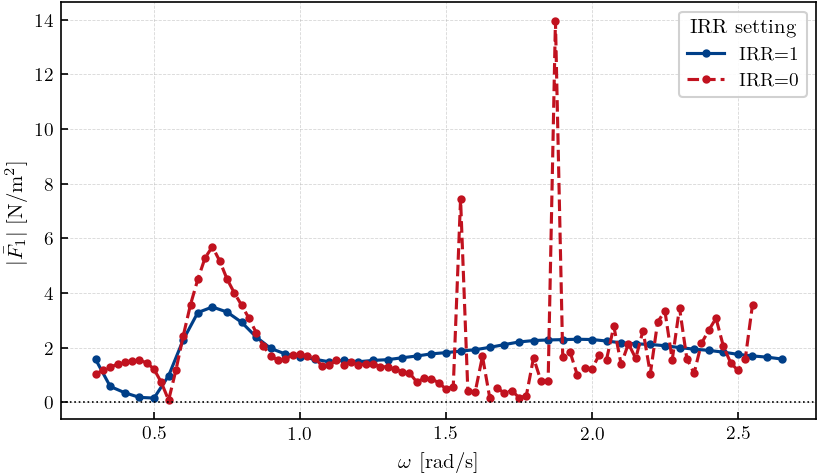

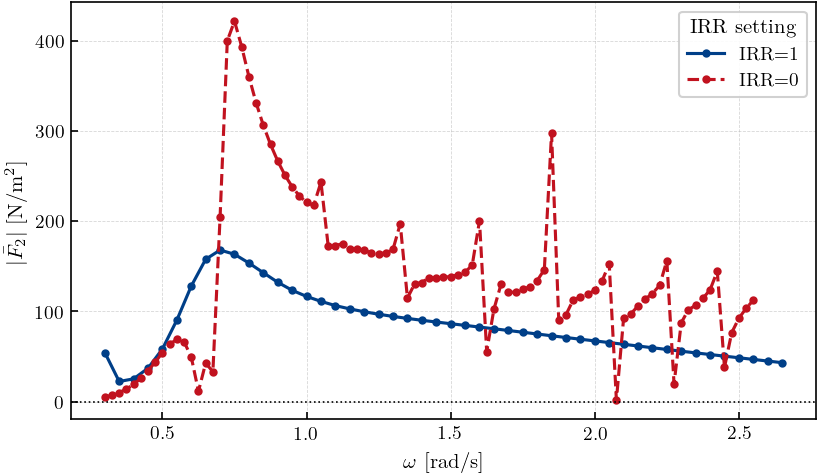

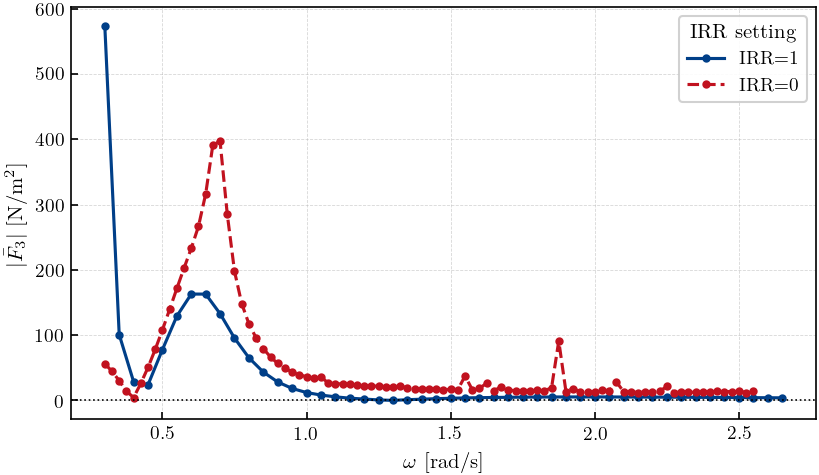

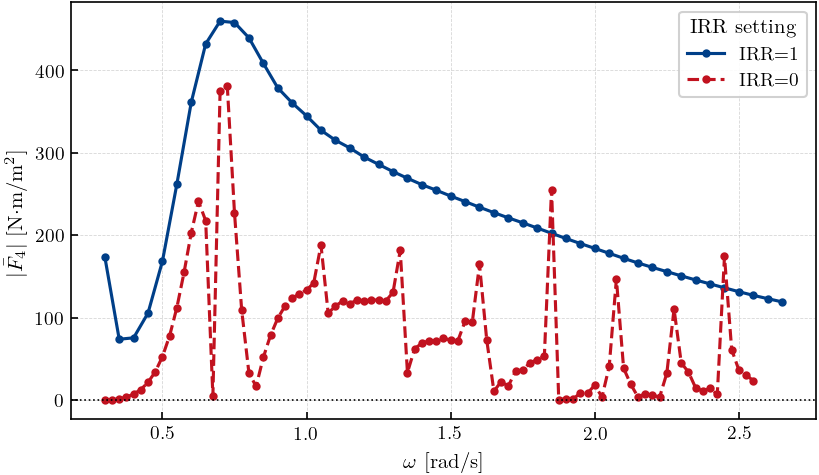

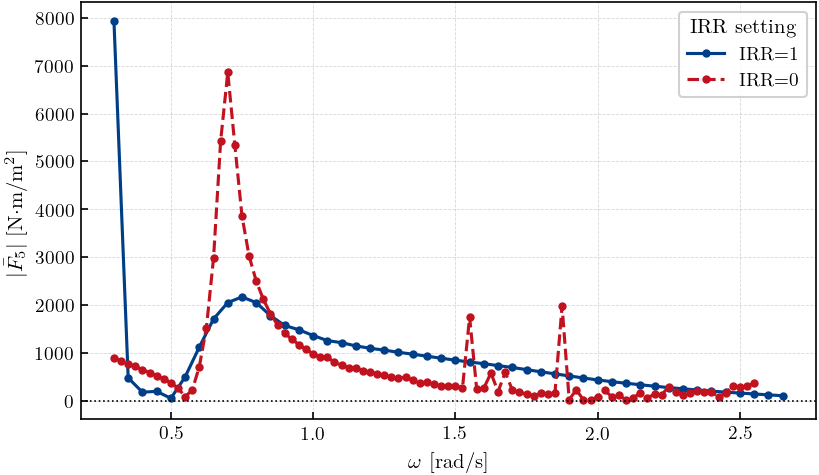

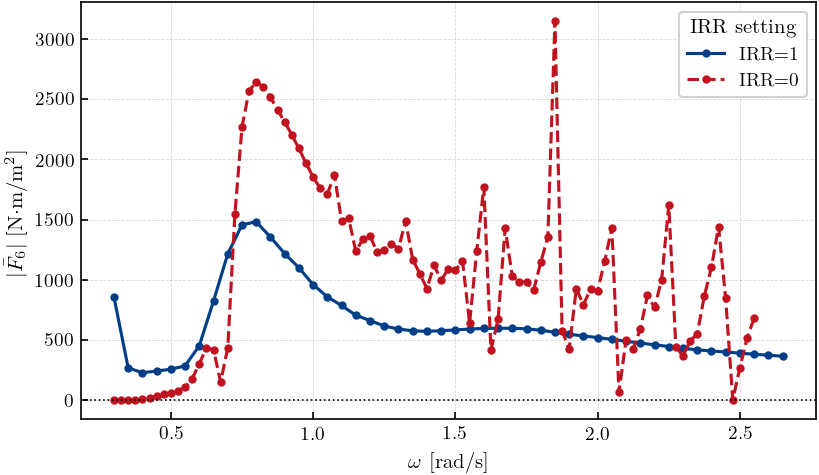

In [4]:
d_irr1_90 = by_heading(irr1, 90.0)
d_irr0_90 = by_heading(irr0, 90.0)

COLORS_IRR = {"IRR=1": "#003f88", "IRR=0": "#c1121f"}
LS_IRR     = {"IRR=1": "-",       "IRR=0": "--"}

for mode, name in DOF_LABELS.items():
    fig, ax = plt.subplots(figsize=full())
    for label, d in [("IRR=1", d_irr1_90), ("IRR=0", d_irr0_90)]:
        mask = d["mode"] == mode
        if not np.any(mask):
            continue
        T     = d["T"][mask]
        F     = d["F"][mask]
        omega = 2*np.pi / T
        idx   = np.argsort(omega)
        ax.plot(omega[idx], F[idx], color=COLORS_IRR[label], ls=LS_IRR[label],
                lw=1.5, marker="o", ms=3, label=label)
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(r"$|\bar{F}_{" + str(mode) + r"}|$ [" + UNITS[mode] + "]")
    ax.legend(title="IRR setting")
    plt.tight_layout()
    save(fig, f"meandrift_{name.lower()}_irr90")
    plt.show()

## Far-field (Haskind) vs Near-field – Beam Sea (90°)

Far-field result from `.8` (Haskind relation) is immune to irregular-frequency contamination and available for surge, sway, and yaw. Agreement with the IRR=1 near-field result validates the pressure-integration method.

In [ ]:
FF_MODES = {1: "Surge", 2: "Sway", 6: "Yaw"}

d_ff_90 = by_heading(farfield, 90.0)
d_nf_90 = d_irr1_90

COLORS_FF = {"Near-field (IRR=1)": "#003f88", "Far-field (Haskind)": "#e76f51"}
LS_FF     = {"Near-field (IRR=1)": "-",        "Far-field (Haskind)": (0, (6, 1.5))}

for mode, name in FF_MODES.items():
    fig, ax = plt.subplots(figsize=full())
    for label, d in [("Near-field (IRR=1)", d_nf_90), ("Far-field (Haskind)", d_ff_90)]:
        mask = d["mode"] == mode
        if not np.any(mask):
            continue
        T     = d["T"][mask]
        F     = d["F"][mask]
        omega = 2*np.pi / T
        idx   = np.argsort(omega)
        ax.plot(omega[idx], F[idx], color=COLORS_FF[label], ls=LS_FF[label],
                lw=1.5, marker="o", ms=3, label=label)
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(r"$|\bar{F}_{" + str(mode) + r"}|$ [" + UNITS[mode] + "]")
    ax.legend(title="Method")
    plt.tight_layout()
    save(fig, f"meandrift_{name.lower()}_ffval90")
    plt.show()